# Section 4 Extension: Noise Robustness

This notebook tests how Gaussian bandit feedback noise affects Section 4. Each round observes only the played cell reward `r_t = clip(A[i_t, j_t] + sigma * Gaussian, 0, 1)`. The comparison keeps UCB, EXP3, and the official OurAlg unchanged, and adds `OurAlg-NoiseAware`, a sigma-adaptive variant that widens its confidence/error bounds as feedback noise increases.

In [1]:
from importlib import reload

from IPython.display import Image, display

import section4_noise_robustness

section4_noise_robustness = reload(section4_noise_robustness)
run_and_plot = section4_noise_robustness.run_and_plot
run_convergence_and_plot = section4_noise_robustness.run_convergence_and_plot


## Run Experiment

Use `quick` for a fast check. Use `medium` or `paper-lite` for report-quality runs.

In [2]:
preset = "paper-lite"  # options: "quick", "medium", "paper-lite"
seed = 42

bundle, regret_path, payoff_path = run_and_plot(preset, seed=seed)
metadata = bundle["metadata"]
results = bundle["results"]
metadata



-- Adversary 1 ------------------------------------------------
  sigma=0.00  UCB: R=    3.22, P=0.2222  EXP3: R=  109.57, P=0.2211  OurAlg: R=   34.83, P=0.2219  OurAlg-NoiseAware: R=   34.83, P=0.2219  
  sigma=0.05  UCB: R=    4.03, P=0.2222  EXP3: R=  114.09, P=0.2211  OurAlg: R=   39.14, P=0.2218  OurAlg-NoiseAware: R=   38.49, P=0.2218  
  sigma=0.10  UCB: R=    4.43, P=0.2222  EXP3: R=  120.02, P=0.2210  OurAlg: R=   45.81, P=0.2218  OurAlg-NoiseAware: R=   46.24, P=0.2218  
  sigma=0.20  UCB: R=    6.01, P=0.2222  EXP3: R=  131.37, P=0.2209  OurAlg: R=   63.22, P=0.2216  OurAlg-NoiseAware: R=   68.52, P=0.2215  
  sigma=0.30  UCB: R=    7.53, P=0.2221  EXP3: R=  141.27, P=0.2208  OurAlg: R=   77.90, P=0.2214  OurAlg-NoiseAware: R=   84.64, P=0.2214  

-- Adversary 2 ------------------------------------------------
  sigma=0.00  UCB: R=   28.38, P=0.2219  EXP3: R=  110.60, P=0.2211  OurAlg: R=   39.41, P=0.2218  OurAlg-NoiseAware: R=   39.41, P=0.2218  
  sigma=0.05  UCB: R=   

{'preset': 'paper-lite',
 'sigma_values': [0.0, 0.05, 0.1, 0.2, 0.3],
 'n_runs': 32,
 'horizon': 100000}

## Generated Plots

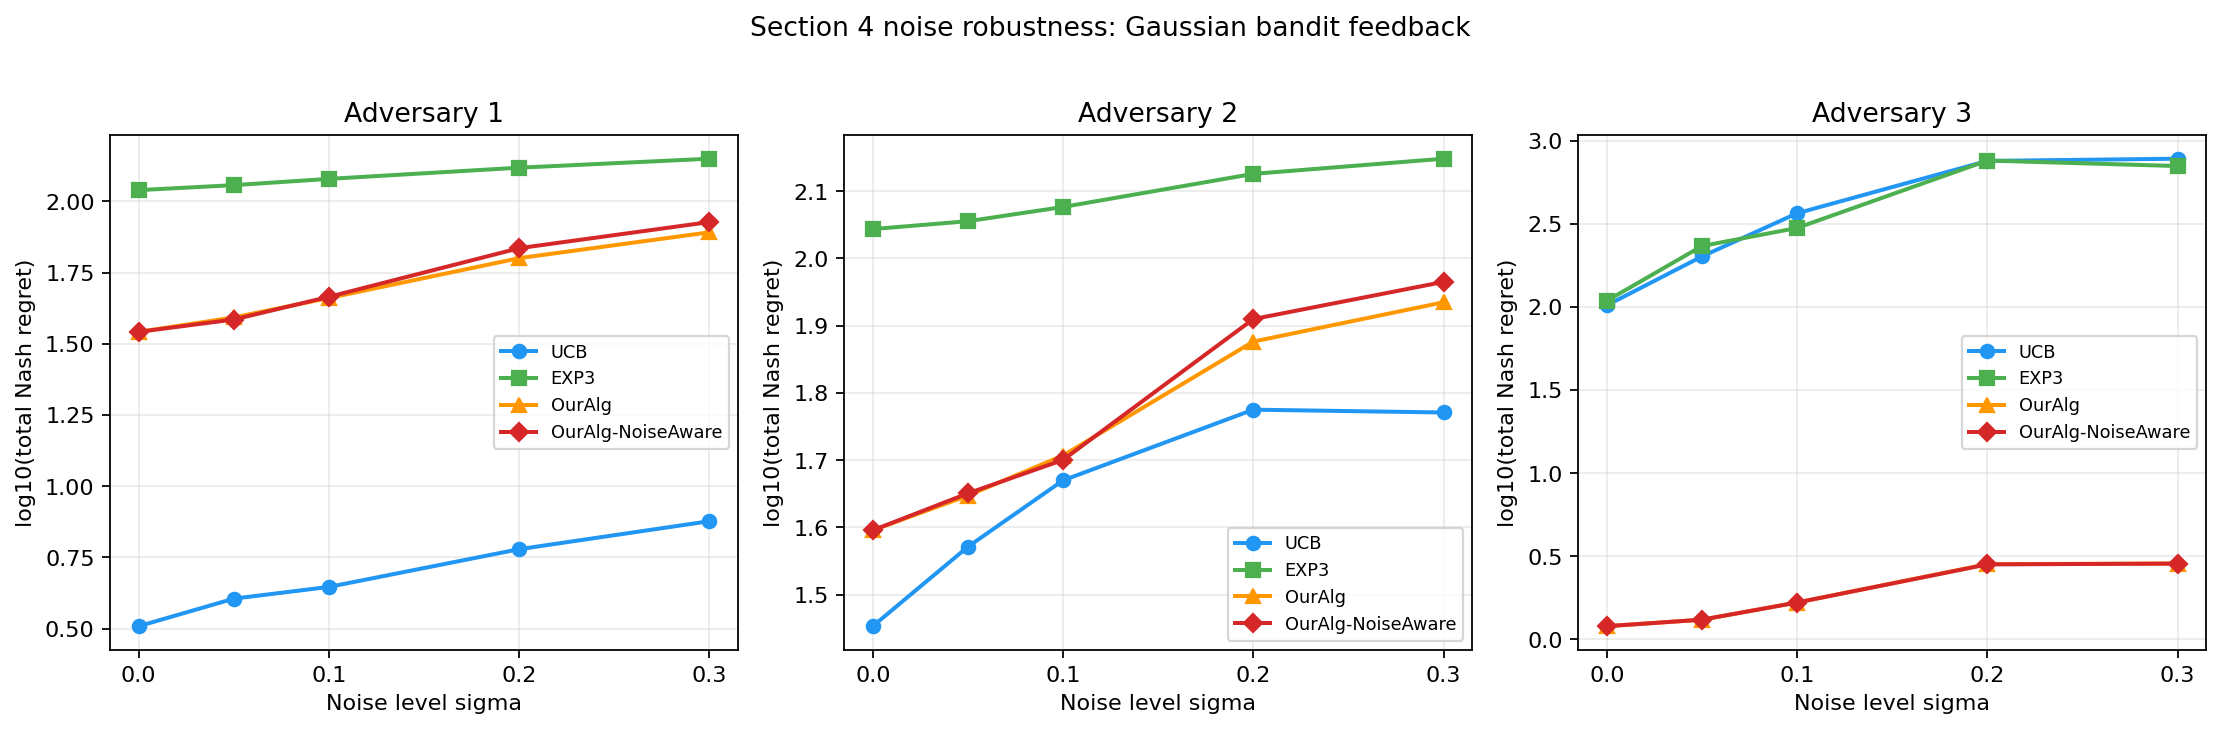

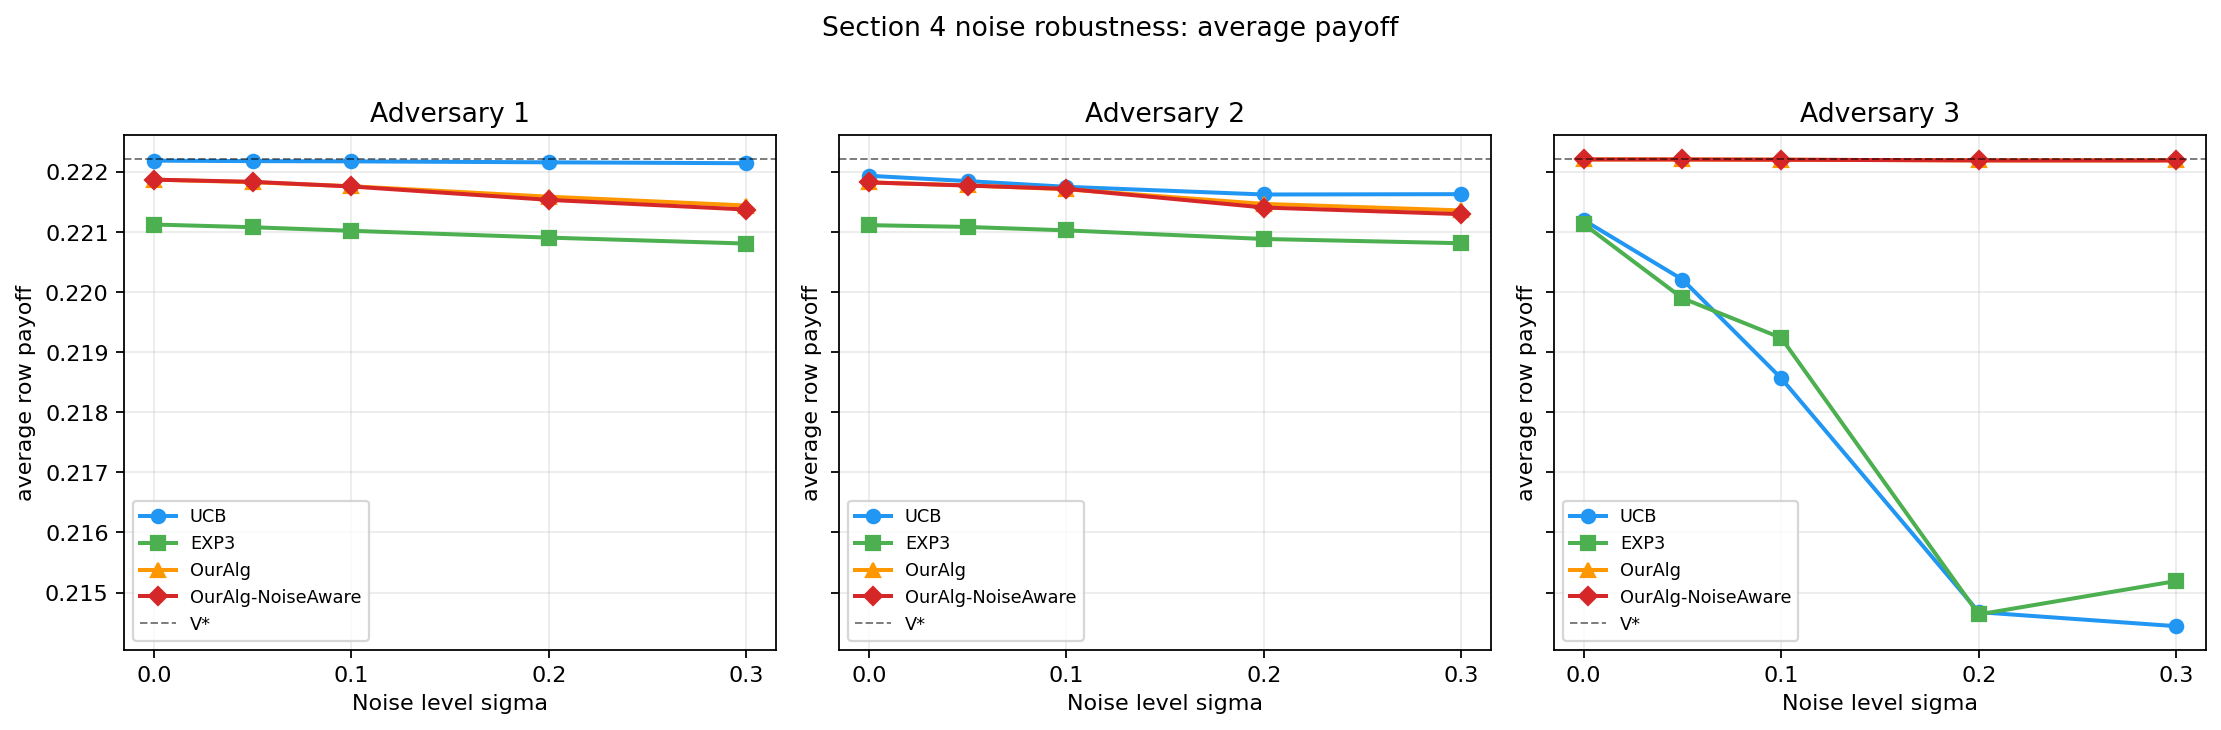

In [3]:
display(Image(filename=str(regret_path)))
display(Image(filename=str(payoff_path)))


## Convergence under high noise

The previous plots summarize final performance as `sigma` changes. The convergence figure below fixes `sigma = 0.3` and shows cumulative Nash regret over time, with one panel for each Section 4 adversary. Curves are averaged over the same number of runs as the selected preset, with shaded one-standard-deviation bands.

In [4]:
convergence_bundle, convergence_path = run_convergence_and_plot(
    preset=preset,
    seed=seed,
    sigma=0.3,
)
convergence_metadata = convergence_bundle["metadata"]



Section 4 convergence
sigma=0.3, T=100000, n_runs=32

-- Adversary 1 ------------------------------------------------
UCB: final R=7.53
EXP3: final R=141.27
OurAlg: final R=77.90
OurAlg-NoiseAware: final R=84.64

-- Adversary 2 ------------------------------------------------
UCB: final R=59.01
EXP3: final R=140.74
OurAlg: final R=86.07
OurAlg-NoiseAware: final R=92.29

-- Adversary 3 ------------------------------------------------
UCB: final R=778.26
EXP3: final R=703.05
OurAlg: final R=2.86
OurAlg-NoiseAware: final R=2.86
Figure saved -> D:\Users\Mateo\Personal\_Seminar_RL\Zero-Sum-MatrixGames\Extensions\Extension_Noise_Robustness_Bandit_feedback\plots\section4_convergence_paper-lite_sigma0p3.png


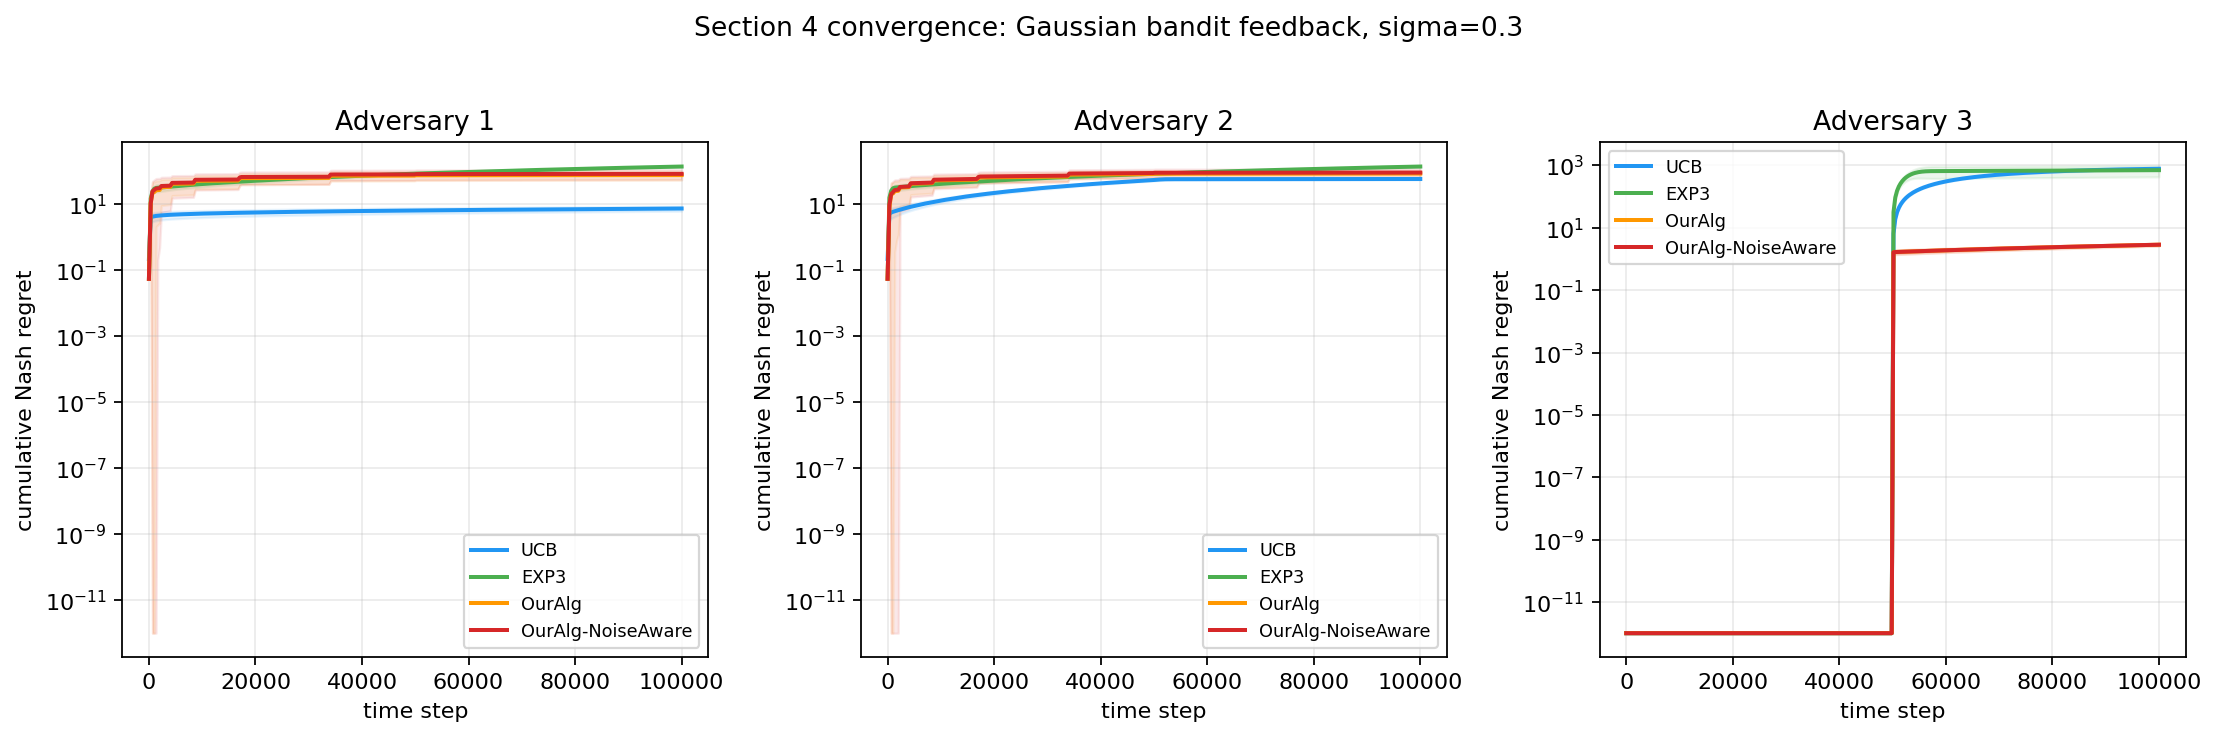

In [5]:
display(Image(filename=str(convergence_path)))


## Interpretation

Section 4 uses bandit feedback, so the learner sees only one noisy payoff per round. The expected behavior is stronger sensitivity to increasing `sigma` than in Section 3, especially for algorithms that need accurate estimates of individual matrix entries.

The new comparison to watch is `OurAlg` versus `OurAlg-NoiseAware`. If the sigma-scaled confidence radius helps, the noise-aware variant should keep regret flatter and average payoff closer to `V*` at higher noise levels, especially against Adversary 3.